In [1]:
import pandas as pd
import numpy as np
import os
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sqlalchemy import create_engine
import datetime
import utils

In [13]:
def bucket_analysis(df, timeframe, target):
    df_agg = utils.descriptive_groupby(df,'bucket_'+timeframe+'min',target)
    utils.bar_chart(df_agg,'mean',timeframe+' Minute Interval', 'Average '+target,yerror=df_agg['std'])
    

In [14]:
load_dotenv()
# f"postgres+psycopg2://{[user]}:{[pass]}@{[host}:{[port]}/{[dbname]}"
engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('POSTGRES_USER')}:{os.getenv('POSTGRES_PASSWORD')}"
    f"@{os.getenv('POSTGRES_HOST')}:{os.getenv('POSTGRES_PORT')}/{os.getenv('POSTGRES_DB')}"
)

In [15]:
query_min = "SELECT * FROM gold.active_1min"
df_min = pd.read_sql(query_min,engine)

In [16]:
df_min['bucket_30min'] = df_min['bar_time'].apply(
    lambda t: (
        datetime.datetime.min + datetime.timedelta(minutes=(t.hour*60 + t.minute)//30 *30)  
    ).time() 
)
df_min['bucket_15min'] = df_min['bar_time'].apply(
    lambda t: (
        datetime.datetime.min + datetime.timedelta(minutes=(t.hour*60 + t.minute)//15 *15)  
    ).time() 
)
df_min['bucket_5min'] = df_min['bar_time'].apply(
    lambda t: (
        datetime.datetime.min + datetime.timedelta(minutes=(t.hour*60 + t.minute)//5 *5)  
    ).time() 
)

In [17]:
df_min['price_movement'] = (df_min['high']-df_min['low']).abs()
df_min = utils.add_winsorized_col(df_min,'price_movement')
df_day = df_min.groupby('bar_date')[['price_movement','price_movement_winsorized']].agg('sum').reset_index()
df_30 = df_min.groupby(['bar_date','bucket_30min'])[['price_movement','price_movement_winsorized']].agg('sum').reset_index()
df_15 = df_min.groupby(['bar_date','bucket_15min'])[['price_movement','price_movement_winsorized']].agg('sum').reset_index()
df_5 = df_min.groupby(['bar_date','bucket_5min'])[['price_movement','price_movement_winsorized']].agg('sum').reset_index()

Daily Analysis

In [18]:
utils.descriptive_analysis(df_day,'price_movement')

count     229.000000
mean     1356.941048
std       875.307329
min        99.750000
25%       840.500000
50%      1154.500000
75%      1575.250000
max      7495.250000
Name: price_movement, dtype: float64

Median:  1154.5
Std Dev:  875.3073290583616
IQR:  734.75


In [19]:
utils.descriptive_analysis(df_day,'price_movement_winsorized')

count     229.000000
mean     1329.791485
std       740.688453
min       103.750000
25%       842.500000
50%      1154.500000
75%      1569.500000
max      5276.500000
Name: price_movement_winsorized, dtype: float64

Median:  1154.5
Std Dev:  740.688452884465
IQR:  727.0


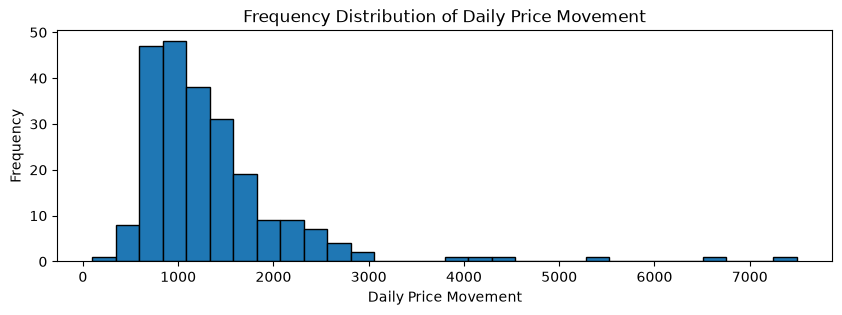

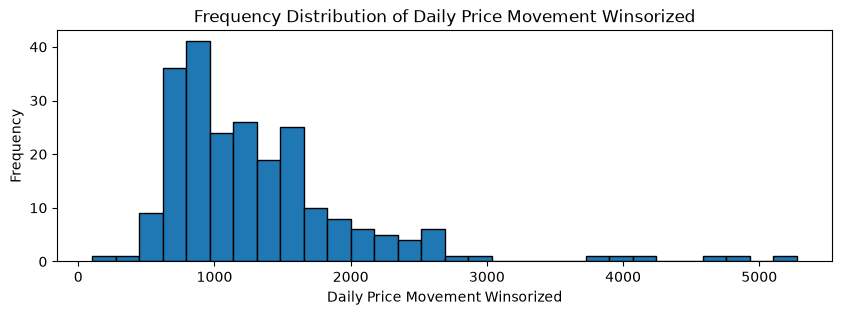

In [20]:
utils.frequency_hist(df_day,'price_movement',30,'Daily Price Movement')
utils.frequency_hist(df_day,'price_movement_winsorized',30,'Daily Price Movement Winsorized')


30 Minute Analysis

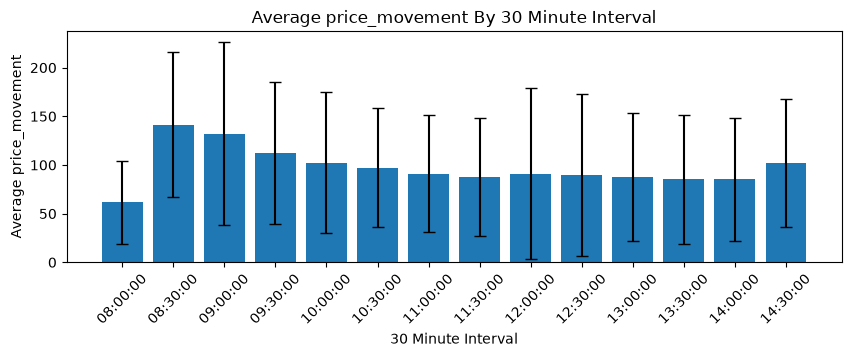

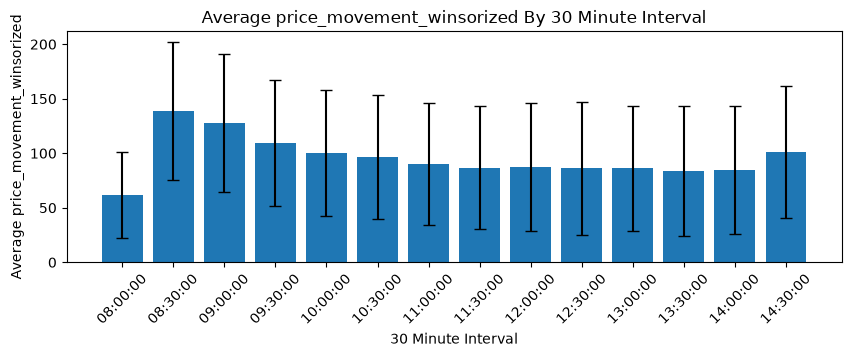

In [21]:
bucket_analysis(df_30,'30','price_movement')
bucket_analysis(df_30,'30','price_movement_winsorized')

15-Minute Analysis

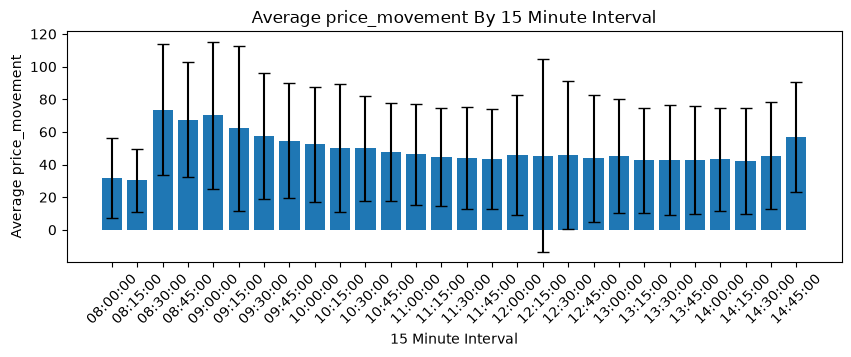

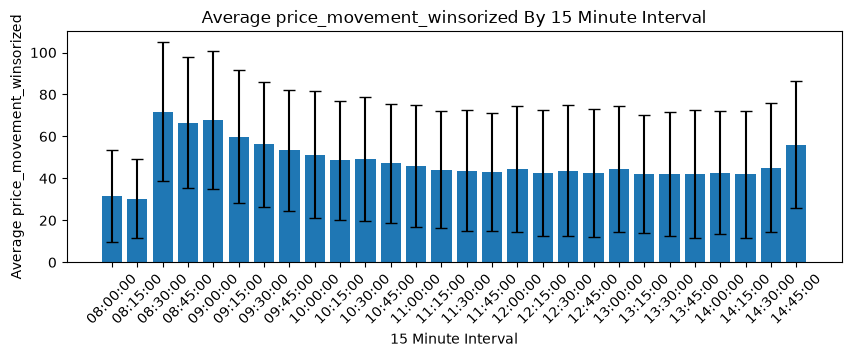

In [22]:
bucket_analysis(df_15,'15','price_movement')
bucket_analysis(df_15,'15','price_movement_winsorized')